In [435]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

I'm loading the data and dropping all the unkonwns. The Unknowns only had 0 values associated and were making the data less transparent. I am doing some type casting, making sure numbers are really numbers and not text, and calculating some initial ratios. Finally, I am showing a table where we see the column names with their types to ensure that everything worked as expected.

In [65]:
df = pd.read_excel('202603-case-study-data-analyst-growth.xlsx')

df_clean = df[
    ~df.astype(str)
      .apply(lambda col: col.str.strip().str.lower().eq('unknown'))
      .any(axis=1)
].copy()

print('-'*30)
print(f'Original Dataframe with Unknowns: {df.shape}')
print(f'Cleaned Dataframe with Unknowns dropped:{df_clean.shape}')
print('-'*30)

# filling missing values
num_cols = df_clean.select_dtypes(include='number').columns
str_cols = df_clean.select_dtypes(include='str').columns

df_clean[num_cols] = df_clean[num_cols].fillna(value=0)
df_clean[str_cols] = df_clean[str_cols].fillna(value='Unknown')

df_clean = df_clean.rename(columns={'Marketing Spendings':'Marketing Spending'})
# ratios
df_clean['Cost per Subscription'] = df_clean['Marketing Spending'] / df_clean['Subscriber']
df_clean['Monthly Conversion Rate'] = df_clean['Monthly Paid Conversions'] / df_clean['Monthly Conversions']
df_clean['Yearly Conversion Rate'] = df_clean['Yearly Paid Conversions'] / df_clean['Yearly Conversions']
df_clean['Subscriber thru Share'] = round(df_clean['Subscriber'] * df_clean['Share Coupon Used'],0)
df_clean['Subscriber Student'] = round(df_clean['Subscriber'] * df_clean['Share Student Coupon Used'],0)

# Type conversions and renaming
df_clean = df_clean.astype({'Business Year':'str'
                   ,'Monthly Conversions':'int64'
                   ,'Yearly Conversions':'int64'
                   ,'Monthly Paid Conversions':'int64'
                   ,'Yearly Paid Conversions':'int64'})
# renaming
df_clean.dtypes

------------------------------
Original Dataframe with Unknowns: (1152, 17)
Cleaned Dataframe with Unknowns dropped:(828, 17)
------------------------------


row_num                        int64
Business Year                    str
Business Month                 int64
Market                           str
Conversion Channel 1             str
Conversion Channel 2             str
Conversion Channel 3             str
Marketing Spending             int64
Subscriber                     int64
Monthly Conversions            int64
Yearly Conversions             int64
Share Coupon Used            float64
Share Student Coupon Used    float64
Monthly Paid Conversions       int64
Yearly Paid Conversions        int64
New Revenue Create Date      float64
New Revenue Invoice Date     float64
Cost per Subscription        float64
Monthly Conversion Rate      float64
Yearly Converison Rate       float64
Subscriber thru Share        float64
Subscriber Student           float64
dtype: object

Here I am looking at the Marketing Spending and Subscriber distribution by Month to generate an inital understanding of the data and any seasonality that may come with it. There are peaks in April, Summer and Oktober for the German Market while the French market seems to be relatively consistent with a peak in August and elevated levels of spending following the August Peak.<br>
The English market seems to have launched in Oktober in a Late Year Launch.

Business Month,1,2,3,4,5,6,7,8,9,10,11,12
Market,,,,,,,,,,,,
English,0,0,0,0,0,0,0,0,23156,118722,107356,131263
French,141059,154913,153137,143754,151028,175746,207260,267522,230612,231715,215943,184816
German,206753,222627,227978,266184,237124,320901,333792,342230,274193,316197,284248,277720


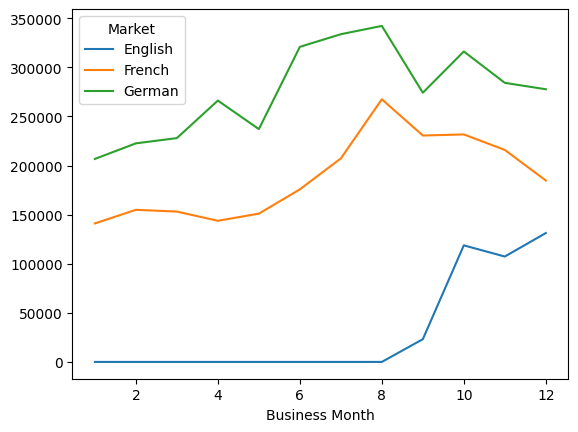

In [227]:
market_spend = df_clean.groupby(['Market', 'Business Month'], as_index=False)[['Marketing Spending']].sum()

market_spend.pivot_table(index='Business Month',columns='Market',values='Marketing Spending',aggfunc=sum).plot()
market_spend.pivot_table(index='Market',columns='Business Month',values='Marketing Spending',aggfunc=sum)

Business Month,1,2,3,4,5,6,7,8,9,10,11,12
Market,,,,,,,,,,,,
English,274,223,182,183,247,362,540,668,3833,10603,9456,10088
French,10023,9468,9859,8130,9682,10785,14636,20247,14779,15503,12670,10565
German,21861,22747,26763,23224,24373,30057,31197,33739,25040,33033,24069,23919


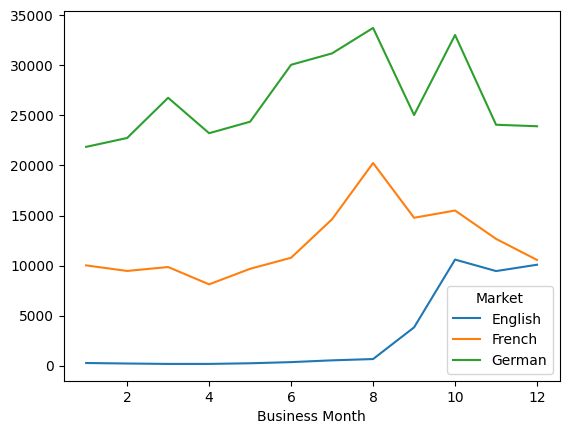

In [228]:
market_subs = df_clean.groupby(['Market', 'Business Month'], as_index=False)[['Subscriber']].sum()

market_subs.pivot_table(index='Business Month',columns='Market',values='Subscriber',aggfunc=sum).plot()
market_subs.pivot_table(index='Market',columns='Business Month',values='Subscriber',aggfunc=sum)

# Paid Conversions
- Yearly Paid Conversion are the top 3 rows followed by Monthly Paid Conversions.
- Yearly Paid Conversions are more popular than Monthly Paid Conversions
- Often Yearly Paid Conversions are better deals and are discounted (example: get a year and pay 10 months).

In [231]:
ypc_pivot= df_clean.pivot_table(index='Market',columns='Business Month', values='Yearly Paid Conversions',aggfunc='sum')
mpc_pivot = df_clean.pivot_table(index='Market',columns='Business Month', values='Monthly Paid Conversions',aggfunc='sum')

pd.concat([ypc_pivot,mpc_pivot],axis=0)


Business Month,1,2,3,4,5,6,7,8,9,10,11,12
Market,,,,,,,,,,,,
English,30,29,31,30,50,61,89,107,549,1432,1710,1841
French,2240,2626,2038,2531,2376,2821,4076,5160,3691,3472,3760,2822
German,4929,5818,5849,7317,5569,7123,7986,8211,6031,7323,6204,5330
English,39,45,31,26,28,36,65,60,271,824,719,671
French,827,750,630,607,865,919,933,1193,861,671,555,572
German,1685,1849,1697,1730,2057,2041,1963,1974,1561,1710,1425,1673


In [230]:
print(f'English Yearly / Monthly Paid Conversions: {ypc_pivot.loc['English'].sum()} / {mpc_pivot.loc['English'].sum()}')
print(f'French Yearly / Monthly Paid Conversions: {ypc_pivot.loc['French'].sum()} / {mpc_pivot.loc['French'].sum()}')
print(f'German Yearly / Monthly Paid Conversions: {ypc_pivot.loc['German'].sum()} / {mpc_pivot.loc['German'].sum()}')

English Yearly / Monthly Paid Conversions: 5959 / 2815
French Yearly / Monthly Paid Conversions: 37613 / 9383
German Yearly / Monthly Paid Conversions: 77690 / 21365


Looing at the Marketing Spend and Subscriber numbers I see that Germany is outperforming the 55% Marketing Spend with 64% Subscribers where France accounts for 38% of Marketing Spend but only 29% Subscribers.

In [255]:
gb_market = df_clean.groupby(by='Market').agg({'Marketing Spending':'sum', 'Subscriber':'sum'})
gb_total = df_clean[['Marketing Spending', 'Subscriber']].sum()

gb_market['Spend Share %'] = gb_market['Marketing Spending'] / gb_total.loc['Marketing Spending']
gb_market['Subscriber %'] = gb_market['Subscriber'] / gb_total.loc['Subscriber']

print(gb_market)

         Marketing Spending  Subscriber  Spend Share %  Subscriber %
Market                                                              
English              380497       36659       0.063971      0.072877
French              2257505      146347       0.379543      0.290932
German              3309947      320022       0.556485      0.636191


# Paid Conversions vs Conversions

In [67]:
monthly_conversions = df_clean.groupby(['Market','Business Month','Conversion Channel 1'], as_index= False)[['Monthly Conversions','Monthly Paid Conversions']].sum()
yearly_conversions = df_clean.groupby(['Market','Business Month','Conversion Channel 1'], as_index= False)[['Yearly Conversions','Yearly Paid Conversions']].sum()

monthly_conversions['Conversion Rate'] = monthly_conversions['Monthly Paid Conversions']/monthly_conversions['Monthly Conversions']
yearly_conversions['Conversion Rate'] = yearly_conversions['Yearly Paid Conversions']/yearly_conversions['Yearly Conversions']

Monthly Conversion seem to have a 100% conversion Rate to Paid Subscriptions.

<Axes: xlabel='Market-Conversion Channel 1', ylabel='Business Month'>

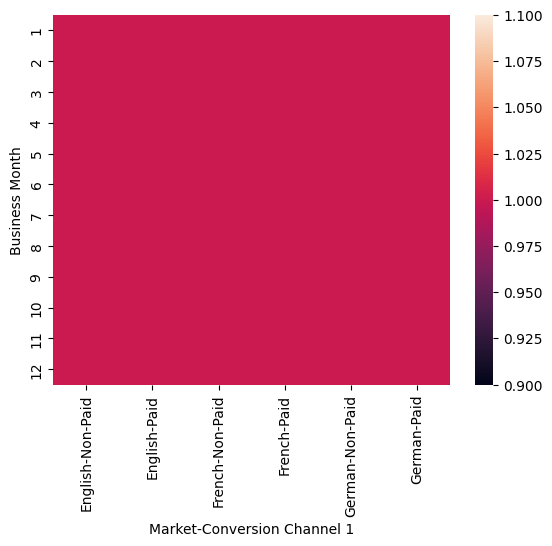

In [68]:
monthly_conversions_rate = monthly_conversions.pivot_table(index='Business Month',columns=['Market','Conversion Channel 1'],values='Conversion Rate')

sns.heatmap(data=monthly_conversions_rate)

We see that a lot of people sign up for yearly subscriptions. When we look at the Yearly Paid Conversion Rate (PCR) though, the conversion Rate, depending on the market, is 34% at its highest. Median / Average PCR is 23%.

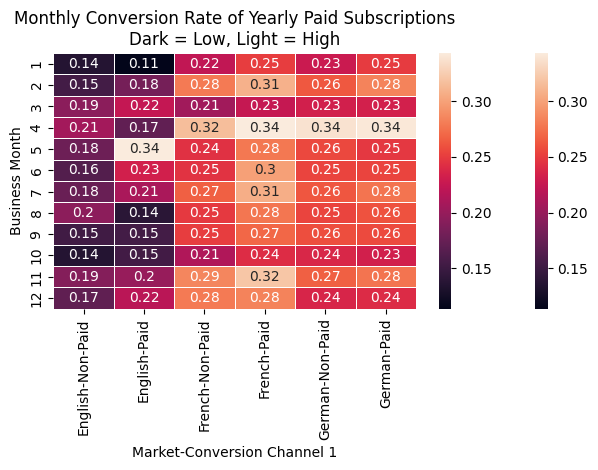

In [217]:
yearly_conversions_rate = yearly_conversions.pivot_table(index='Business Month',columns=['Market','Conversion Channel 1'],values='Conversion Rate')
sns.heatmap(data=yearly_conversions_rate)

sns.heatmap(data=yearly_conversions_rate,annot=True, linewidths=.5)
plt.title('Monthly Conversion Rate of Yearly Paid Subscriptions\nDark = Low, Light = High')
plt.tight_layout()
plt.show()

## Overview of Yearly Paid Conversions by Market and by Conversion Channel
- In the German and French market we see Increases in the Paid Conversion Rate (PCR) around April and November. In April this is driven by a dip in Yearly Conversions and an increase in marketing spending (German Market) while the PCR stays the same relative to earlier and later months.
- The PCR in the English market fluctuates wildly before September stabilizing in October. It's hard to draw any performance infrences.
- Towards the end of the Year the number of people in the English market that start a trial shoots up to parity with the French Market which indicates that there is strong interest in Femtasy subscriptions.
- The addressable English market seems to be larger and underserved. Trial numbers are similar to French numbers with 44% of the marketing spend (time period = Sept to Dec). PCR still needs to be optimized

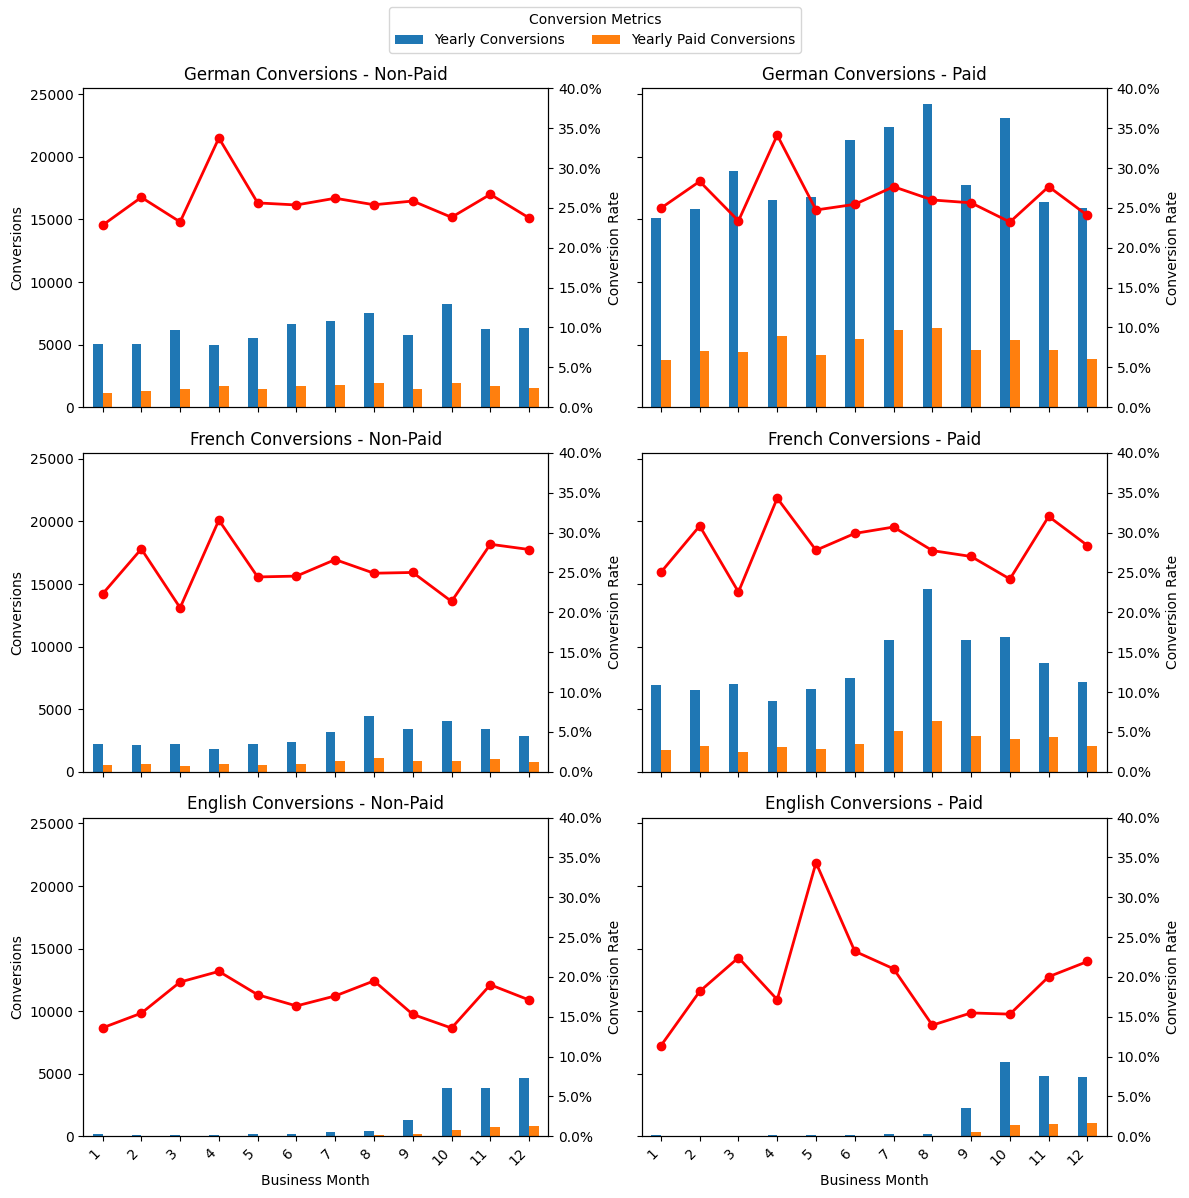

In [413]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

markets = ['German', 'French', 'English']
channels = ['Non-Paid', 'Paid']

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 12),
    sharex=True,
    sharey=True
)

for row, market in enumerate(markets):
    for col, channel in enumerate(channels):

        ax1 = axes[row, col]

        data = yearly_conversions[
            (yearly_conversions['Market'] == market) &
            (yearly_conversions['Conversion Channel 1'] == channel)
        ].copy()

        # Optional but recommended if Business Month is sortable
        data = data.sort_values('Business Month')

        x = np.arange(len(data))

        # --- BAR CHART ---
        data.plot(
            x='Business Month',
            y=['Yearly Conversions', 'Yearly Paid Conversions'],
            kind='bar',
            ax=ax1,
            legend=False
        )

        ax1.set_ylabel('Conversions')
        ax1.set_title(f'{market} Conversions - {channel}')

        ax1.set_xticks(x)
        ax1.set_xticklabels(data['Business Month'], rotation=45, ha='right')

        # --- SECOND Y AXIS ---
        ax2 = ax1.twinx()

        ax2.plot(
            x,
            data['Conversion Rate'],
            marker='o',
            color='red',
            linewidth=2,
            label='Conversion Rate'
        )

        ax2.set_ylabel('Conversion Rate')

        # Use this if Conversion Rate is stored as decimal, e.g. 0.12 = 12%
        ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

        # Optional: keep conversion rate axis reasonable
        # ax2.set_ylim(0, data['Conversion Rate'].max() * 1.2)
        ax2.set_ylim(0, .4)

# Shared legend for bar columns
handles1, labels1 = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles1,
    labels1,
    title='Conversion Metrics',
    loc='upper center',
    ncol=2
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Conversion Metrics per Country.png')
plt.show()

In [418]:
marketing_spend_market_month = market_spend.pivot_table(index='Market',columns='Business Month',values='Marketing Spending',aggfunc=sum)


print('-'*30)
print(f'English Marketing Spend from September to December {marketing_spend_market_month.loc['English'][8:12].sum():,.0f}')
print(f'French Marketing Spend from September to December {marketing_spend_market_month.loc['French'][8:12].sum():,.0f}')
print(f'English share of Marketing Spend compared to French {marketing_spend_market_month.loc['English'][8:12].sum() / marketing_spend_market_month.loc['French'][8:12].sum():.2%}')
print('-'*30)


------------------------------
English Marketing Spend from September to December 380,497
French Marketing Spend from September to December 863,086
English share of Marketing Spend compared to French 44.09%
------------------------------


# Marketing Spend and Subscriptions
- I was not expecting to see subscriber numbers for paid channels in English before September as there was no Marketing Spend for months prior to September. They are low, but there none-the-less.
- Germany, even though it is already established, has the lowest marketing spend / subscription ratio at 13.81 followed by the English (18.76 marketing spend per subscription) market and French (20.63 per subscription)
- I suggest a recalibration of paid marketing in the French market to optimize efforts and bring down the marketing spend per subscription and increase number of paid subscriptions.
- Influencer Marketing is performing better by 4+ points compared to Performance Marketing. This may be because potential subscribers have a relationship with their trusted influencers and trust them rather than a performance marketing ad.
- In the following cells we see a summaries of Cost per Subscriber per Conversion Channel Layer

In [86]:
# Conversion Channel 1 Summary

cc1_summary = df_clean.pivot_table(index='Business Month', columns=['Conversion Channel 1','Market'],values=['Marketing Spending','Subscriber'],aggfunc=sum,fill_value=0, margins=True, margins_name='Total')

for m in ['English', 'French', 'German']:
    cc1_summary[('Cost per Subscriber', 'Paid', m)] = cc1_summary[('Marketing Spending','Paid', m)] / cc1_summary[('Subscriber','Paid', m)]

cc1_summary

Marketing Spending                                 \
Conversion Channel 1           Non-Paid                  Paid            
Market                          English French German English   French   
Business Month                                                           
1                                     0      0      0       0   141059   
2                                     0      0      0       0   154913   
3                                     0      0      0       0   153137   
4                                     0      0      0       0   143754   
5                                     0      0      0       0   151028   
6                                     0      0      0       0   175746   
7                                     0      0      0       0   207260   
8                                     0      0      0       0   267522   
9                                     0      0      0   23156   230612   
10                                    0      0      0  118722   231715   
11                                    0      0      0  107356   215943   
12                                    0      0      0  131263   184816   
Total                                 0      0      0  380497  2257505   

                                       Subscriber                        \
Conversion Channel 1             Total   Non-Paid                  Paid   
Market                 German             English French German English   
Business Month                                                            
1                      206753   347812        175   2469   5511      99   
2                      222627   377540        148   2363   5555      75   
3                      227978   381115        113   2354   6705      69   
4                      266184   409938        108   1991   5372      75   
5                      237124   388152        168   2458   6091      79   
6                      320901   496647        238   2623   7180     124   
7                      333792   541052        361   3428   7423     179   
8                      342230   609752        436   4766   8067     232   
9                      274193   527961       1391   3619   6187    2442   
10                     316197   666634       4141   4225   8802    6462   
11                     284248   607547       4164   3626   6704    5292   
12                     277720   593799       4932   3019   6870    5156   
Total                 3309947  5947949      16375  36941  80467   20284   

                                             Cost per Subscriber             \
Conversion Channel 1                   Total                Paid              
Market                French  German                     English     French   
Business Month                                                                
1                       7554   16350   32158            0.000000  18.673418   
2                       7105   17192   32438            0.000000  21.803378   
3                       7505   20058   36804            0.000000  20.404664   
4                       6139   17852   31537            0.000000  23.416517   
5                       7224   18282   34302            0.000000  20.906423   
6                       8162   22877   41204            0.000000  21.532222   
7                      11208   23774   46373            0.000000  18.492148   
8                      15481   25672   54654            0.000000  17.280667   
9                      11160   18853   43652            9.482391  20.664158   
10                     11278   24231   59139           18.372331  20.545753   
11                      9044   17365   46195           20.286470  23.876935   
12                      7546   17049   44572           25.458301  24.491916   
Total                 109406  239555  503028           18.758480  20.634197   

                                 
Conversion Channel 1             
Market                   German  
Business Month                   
1     

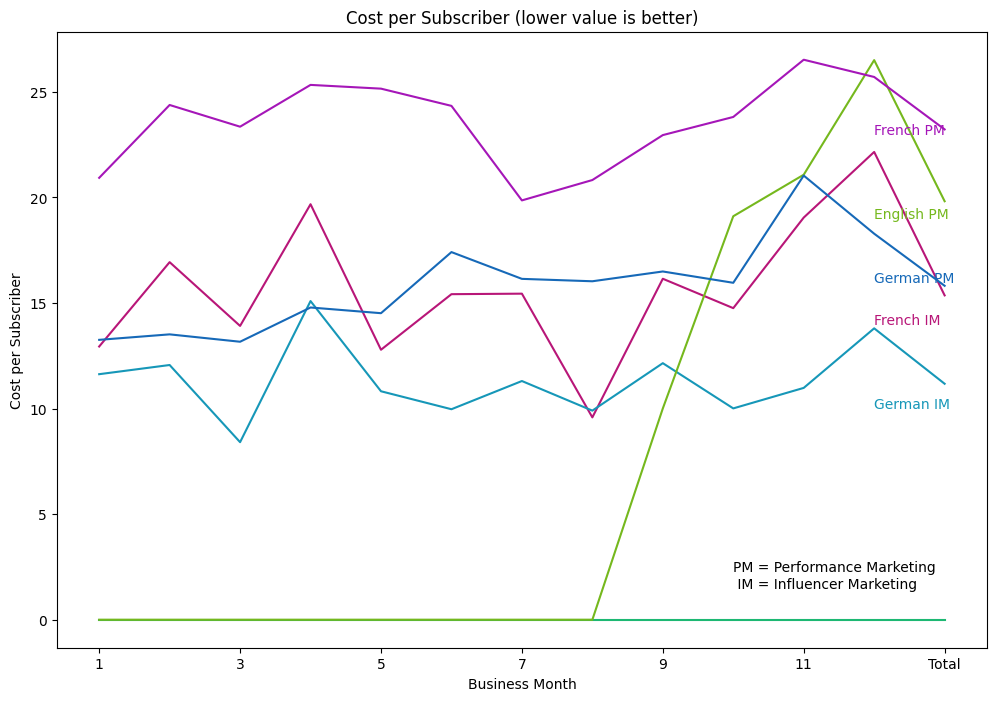

Marketing Spending                   \
Conversion Channel 2         Influencer                    
Market                          English  French   German   
Business Month                                             
1                                     0   27630    71504   
2                                     0   41682    81077   
3                                     0   32634    63874   
4                                     0   40976   107239   
5                                     0   31740    82882   
6                                     0   39615   103783   
7                                     0   53685   116955   
8                                     0   46800   112078   
9                                     0   60695   102953   
10                                    0   60083   118636   
11                                    0   61032    88529   
12                                    0   57300   104742   
Total                                 0  553872  1154252   

                                                                       \
Conversion Channel 2 Performance Marketing                      Total   
Market                             English   French   German            
Business Month                                                          
1                                        0   113429   135249   347812   
2                                        0   113231   141550   377540   
3                                        0   120503   164104   381115   
4                                        0   102778   158945   409938   
5                                        0   119288   154242   388152   
6                                        0   136131   217118   496647   
7                                        0   153575   216837   541052   
8                                        0   220722   230152   609752   
9                                    23156   169917   171240   527961   
10                                  118722   171632   197561   666634   
11                                  107356   154911   195719   607547   
12                                  131263   127516   172978   593799   
Total                               380497  1703633  2155695  5947949   

                     Subscriber                                              \
Conversion Channel 2 Influencer                Performance Marketing          
Market                  English French  German               English French   
Business Month                                                                
1                            23   2135    6148                    76   5419   
2                            26   2461    6720                    49   4644   
3                            22   2345    7595                    47   5160   
4                            27   2082    7105                    48   4057   
5                            34   2482    7659                    45   4742   
6                            44   2569   10409                    80   5593   
7                            56   3476   10344                   123   7732   
8                            76   4883   11316                   156  10598   
9                           128   3758    8472                  2314   7402   
10                          250   4071   11852                  6212   7207   
11                          199   3204    8062                  5093   5840   
12                          204   2586    7589                  4952   4960   
Total                      1089  36052  103271                 19195  73354   

                                     Cost per Subscriber             \
Conversion Channel 2           Total          Influencer              
Market                German                     English     French   
Business Month                                                        
1                      10202   24003                 0.0  12.941452   
2                      10472   24372                 0.0  1

In [269]:
# Conversion Channel 2 Summary

de = ['#1697B8','#1669B8']
fr = ['#B81678','#A516B8']
en = ['#1DB873','#75B81D']

cc2_summary = df_clean[df_clean['Conversion Channel 1'] == 'Paid']
cc2_summary = cc2_summary.pivot_table(index='Business Month', columns=['Conversion Channel 2','Market'],values=['Marketing Spending','Subscriber'],aggfunc=sum,fill_value=0, margins=True, margins_name='Total')

for cc2 in ['Influencer','Performance Marketing']:
    for m in ['English', 'French', 'German']:
        cc2_summary[('Cost per Subscriber', cc2, m)] = cc2_summary[('Marketing Spending',cc2, m)] / cc2_summary[('Subscriber',cc2, m)]


cc2_summary['Cost per Subscriber'].plot(kind='line',color=[en[0],fr[0],de[0]
                                                           ,en[1],fr[1],de[1]]
                                        , figsize=(12,8))
plt.ylabel('Cost per Subscriber')
plt.title('Cost per Subscriber (lower value is better)')
for label, yval, color in zip(['French IM', 'German IM', 'English PM', 'French PM', 'German PM'], [14,10,19,23,16], [fr[0],de[0],en[1],fr[1],de[1]]):
    plt.annotate(text=label, xy=(11,yval), color=color)

plt.annotate(text='PM = Performance Marketing\n IM = Influencer Marketing',xy=(9,1.5), color='k')
plt.legend().remove()
plt.savefig('cost_per_subscriber.png')

plt.show()
cc2_summary

In [186]:
# Conversion Channel 3 Summary

cc3_summary = df_clean[df_clean['Conversion Channel 1'] == 'Paid']

cc3_list = sorted(cc3_summary['Conversion Channel 3'].unique().tolist())
cc3_market = sorted(cc3_summary['Market'].unique().tolist())

cc3_summary = cc3_summary.pivot_table(index='Business Month', columns=['Conversion Channel 3','Market'],values=['Marketing Spending','Subscriber'],aggfunc=sum,fill_value=0, margins=True, margins_name='Total')

for cc3 in cc3_list:
    for m in cc3_market:
        cc3_summary[('Cost per Subscriber', cc3, m)] = cc3_summary[('Marketing Spending',cc3, m)] / cc3_summary[('Subscriber',cc3, m)]

cc3_summary['Cost per Subscriber']

/var/folders/3f/wm1b1zmd1w191lvc2sp9y7ym0000gn/T/ipykernel_44745/1039100850.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cc3_summary[('Cost per Subscriber', cc3, m)] = cc3_summary[('Marketing Spending',cc3, m)] / cc3_summary[('Subscriber',cc3, m)]


Conversion Channel 3 Facebook/Instagram Ads                       Google Ads  \
Market                              English     French     German    English   
Business Month                                                                 
1                                  0.000000  22.042901  14.764895        0.0   
2                                  0.000000  24.506674  14.255108        0.0   
3                                  0.000000  23.651989  14.036724        0.0   
4                                  0.000000  25.945173  15.669421        0.0   
5                                  0.000000  26.867429  15.665614        0.0   
6                                  0.000000  25.215141  17.832697        0.0   
7                                  0.000000  22.430262  16.747416        0.0   
8                                  0.000000  23.366012  17.776370        0.0   
9                                 11.202709  26.166902  19.477072        0.0   
10                                21.523205  26.937900  18.605438        0.0   
11                                23.936678  29.975961  24.771943        0.0   
12                                30.391989  29.378098  21.885725        0.0   
Total                             23.094016  25.378054  17.740693        0.0   

Conversion Channel 3                      Influencer Instagram             \
Market                   French    German              English     French   
Business Month                                                              
1                      7.739514  3.258978                  0.0  12.953586   
2                     13.836842  3.481878                  0.0  16.950793   
3                      7.280000  2.749615                  0.0  13.934244   
4                     11.254279  3.150954                  0.0  19.700000   
5                      9.842975  1.528455                  0.0  12.793229   
6                      7.722022  0.000000                  0.0  15.432411   
7                      7.456386  0.000000                  0.0  15.457817   
8                      5.907969  0.000000                  0.0   9.592130   
9                      4.745833  0.000000                  0.0  16.163782   
10                     5.605396  0.000000                  0.0  14.769666   
11                     5.403883  0.000000                  0.0  19.078462   
12                     5.836852  0.000000                  0.0  22.174923   
Total                  7.304957  1.462531                  0.0  15.376791   

Conversion Channel 3            Influencer Podcast  ... Porn Sites  \
Market                   German            English  ...     German   
Business Month                                      ...              
1                     12.013441                0.0  ...        NaN   
2                     12.402784                0.0  ...        NaN   
3                      8.623464                0.0  ...        NaN   
4                     15.488013                0.0  ...        NaN   
5                     11.125101                0.0  ...        NaN   
6                     10.146950                0.0  ...        NaN   
7                     11.514591                0.0  ...        NaN   
8                      9.796948                0.0  ...        NaN   
9                     12.409957                0.0  ...        NaN   
10                     9.969064                0.0  ...        NaN   
11                    11.189206                0.0  ...        NaN   
12                    14.104767                0.0  ...        NaN   
Total                 11.368156                0.0  ...        NaN   

Conversion Channel 3 Snapchat Ads               TikTok Ads             \
Market                    English French German    English     French   
Business Month                                                          
1                             NaN    NaN    NaN        0.0  23.025850   
2                             NaN    NaN    NaN        0.0  31.320000   


# Cost per Subscriber Layer 3 Per Month
Here we see a detailed view of the markets and their CpS.

In [190]:
german_cc3 = cc3_summary['Cost per Subscriber'].loc[
    :,
    (cc3_summary['Cost per Subscriber'].columns.get_level_values('Market') == 'German')
]
german_cc3

Conversion Channel 3,Facebook/Instagram Ads,Google Ads,Influencer Instagram,Influencer Podcast,Influencer Youtube,Partnership Ads,Pinterest Ads,Porn Sites,Snapchat Ads,TikTok Ads,Youtube Ads
Market,German,German,German,German,German,German,German,German,German,German,German
Business Month,,,,,,,,,,,
1,14.764895,3.258978,12.013441,0.000000,NaN,NaN,NaN,NaN,NaN,18.646940,0.0
2,14.255108,3.481878,12.402784,0.000000,NaN,NaN,NaN,NaN,NaN,20.693302,0.0
3,14.036724,2.749615,8.623464,0.000000,NaN,NaN,NaN,NaN,NaN,20.295797,0.0
4,15.669421,3.150954,15.488013,0.000000,0.0,NaN,NaN,NaN,NaN,21.334548,0.0
5,15.665614,1.528455,11.125101,0.000000,NaN,NaN,NaN,NaN,NaN,27.667107,0.0
6,17.832697,0.000000,10.146950,0.000000,NaN,NaN,NaN,NaN,NaN,30.746879,0.0
7,16.747416,0.000000,11.514591,2.662722,inf,NaN,NaN,NaN,NaN,27.691464,0.0
8,17.776370,0.000000,9.796948,0.000000,inf,NaN,NaN,NaN,NaN,19.201172,0.0


In [191]:
french_cc3 = cc3_summary['Cost per Subscriber'].loc[
    :,
    (cc3_summary['Cost per Subscriber'].columns.get_level_values('Market') == 'French')
]
french_cc3

Conversion Channel 3,Facebook/Instagram Ads,Google Ads,Influencer Instagram,Influencer Podcast,Influencer Youtube,Partnership Ads,Pinterest Ads,Porn Sites,Snapchat Ads,TikTok Ads,Youtube Ads
Market,French,French,French,French,French,French,French,French,French,French,French
Business Month,,,,,,,,,,,
1,22.042901,7.739514,12.953586,0.0,NaN,NaN,NaN,NaN,NaN,23.025850,0.0
2,24.506674,13.836842,16.950793,0.0,NaN,NaN,NaN,NaN,NaN,31.320000,0.0
3,23.651989,7.280000,13.934244,0.0,NaN,NaN,NaN,NaN,NaN,30.905765,0.0
4,25.945173,11.254279,19.700000,0.0,NaN,NaN,NaN,NaN,NaN,31.927162,0.0
5,26.867429,9.842975,12.793229,0.0,NaN,NaN,NaN,NaN,NaN,27.353805,0.0
6,25.215141,7.722022,15.432411,0.0,NaN,NaN,NaN,NaN,NaN,31.597387,0.0
7,22.430262,7.456386,15.457817,0.0,NaN,NaN,NaN,NaN,NaN,7.291925,0.0
8,23.366012,5.907969,9.592130,0.0,NaN,NaN,NaN,NaN,NaN,0.000000,0.0


In [193]:
english_cc3 = cc3_summary['Cost per Subscriber'].loc[
    :,
    (cc3_summary['Cost per Subscriber'].columns.get_level_values('Market') == 'English')
]
english_cc3

Conversion Channel 3,Facebook/Instagram Ads,Google Ads,Influencer Instagram,Influencer Podcast,Influencer Youtube,Partnership Ads,Pinterest Ads,Porn Sites,Snapchat Ads,TikTok Ads,Youtube Ads
Market,English,English,English,English,English,English,English,English,English,English,English
Business Month,,,,,,,,,,,
1,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN
3,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN
4,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN
5,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN
6,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN
7,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN
8,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN


# Budget Allocation (what can go)
## Germany
- Meta channels seem to be performing well
- Paid Influencer on Instagram is performing well. While this is currently only in the Germany market, consider increasing budget since people tend to trust their influencer especially if there is authenticity / the influencer has authority on a topic.
- Influencer Podcast almost has a 1:1 ratio of marketing spend and subscribers. No doubt this ratio will decrease with additional spend and may be difficult because Podcasts don't scale, but it will still be very efficient.
- I consider axing YouTube Influencer and Partnership Ads since they are not showing any returns.
## France
- Meta Channels are performing worst out of all paid channels. I recommend to recalibrate this channel and analyzing why it is performing worse than in Germany.
- While meta ad channels aren't performing well Instagram Influencer channel is. Consider increasing budget for the same reasons as in Germany.
- TikTok is performing well, but not great relative to other channels. Consider reviewing the TikTok channel.
## English Market
- Only available channel is Meta. It is already performing better (on cost per subscriber metric) than in France. Additional channels such as Instagram Influencer and Podcasts are worth considering.
## across all markets
- Google Ads is also perfoming well when looking at cost to subscriber. Google Ads indicates that someone was looking for Femtasy either directly or a related search term - high intent to convert.

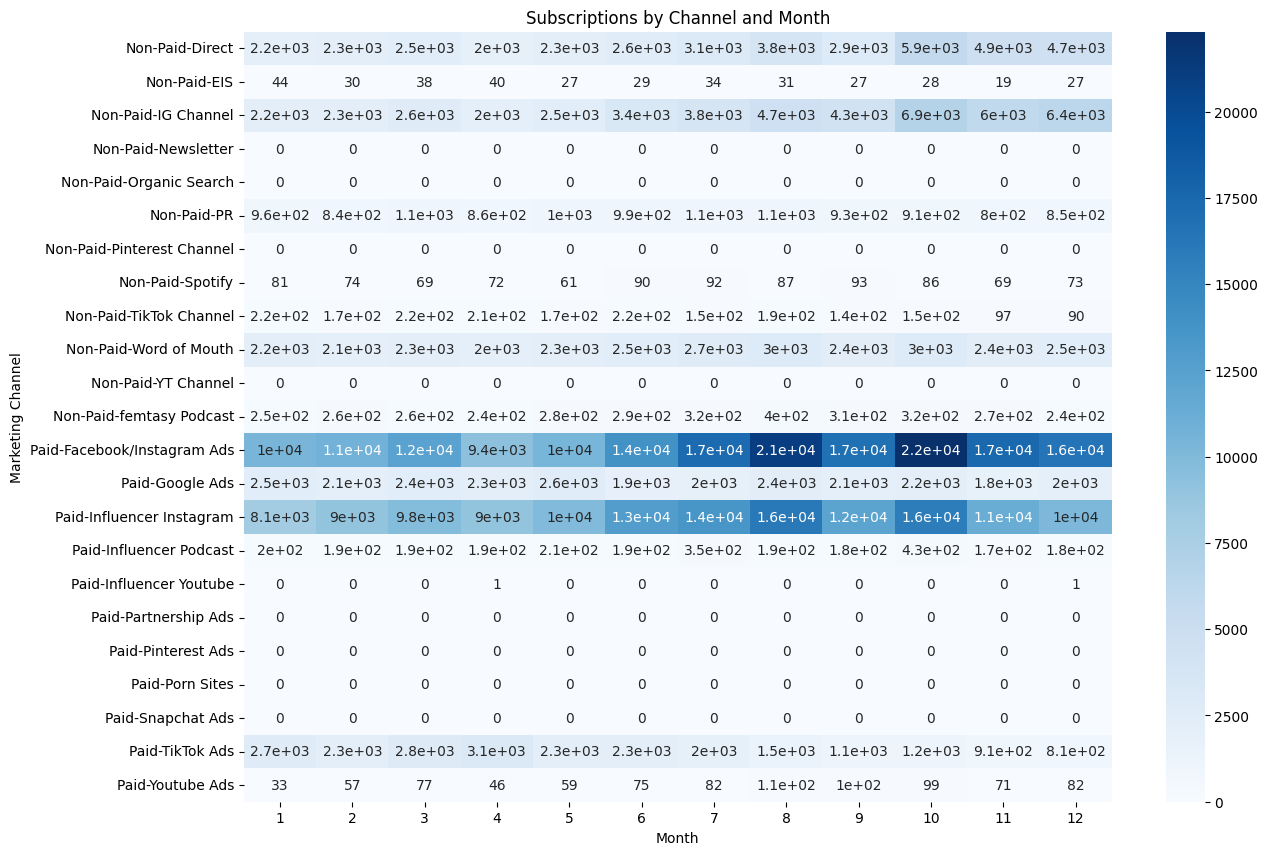

In [153]:
heatmap_data = df_clean.pivot_table(
    index=['Conversion Channel 1','Conversion Channel 3'],
    columns='Business Month',
    values='Subscriber',
    aggfunc='sum'
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_data,
    cmap='Blues',
    annot=True
)

plt.title('Subscriptions by Channel and Month')
plt.xlabel('Month')
plt.ylabel('Marketing Channel')
plt.show()

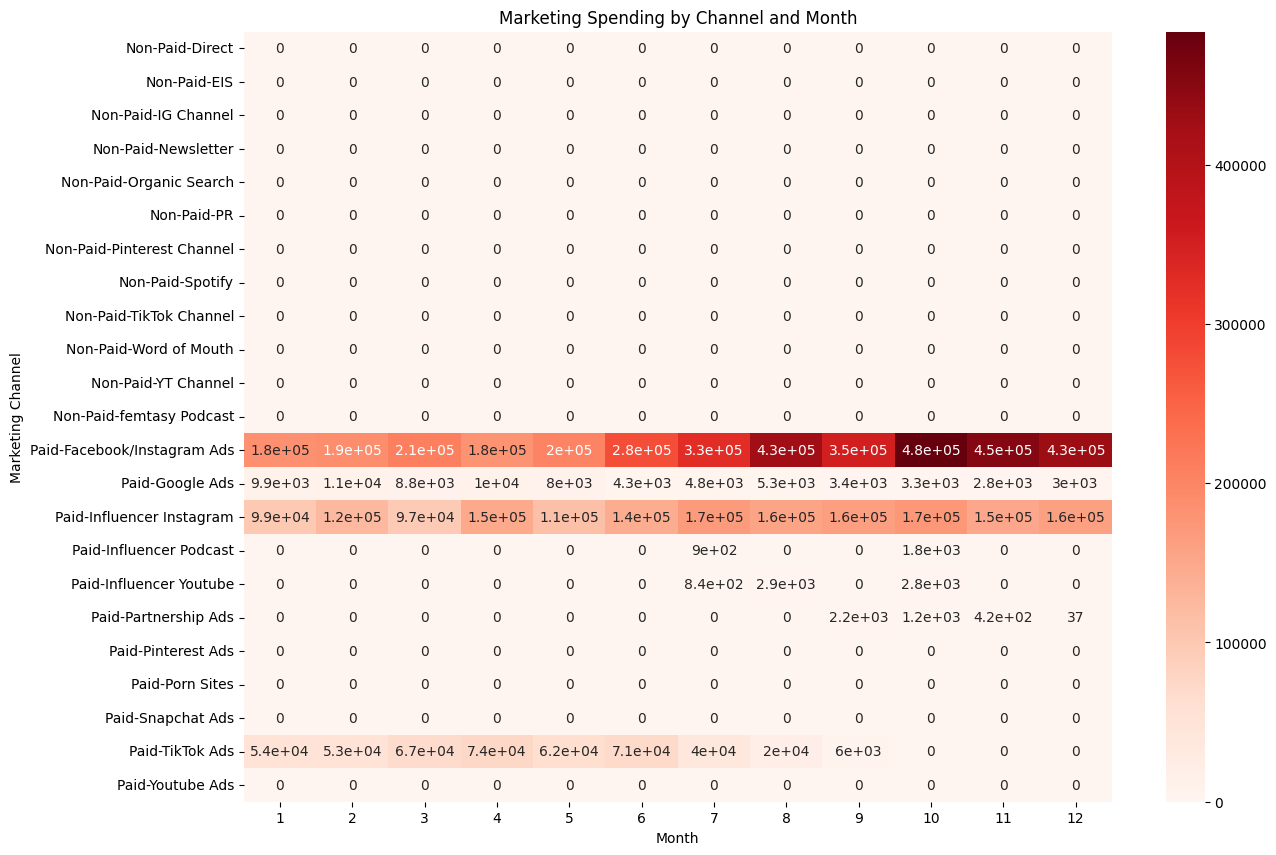

In [154]:
heatmap_data = df_clean.pivot_table(
    index=['Conversion Channel 1','Conversion Channel 3'],
    columns='Business Month',
    values='Marketing Spending',
    aggfunc='sum'
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_data,
    cmap='Reds',
    annot=True
)

plt.title('Marketing Spending by Channel and Month')
plt.xlabel('Month')
plt.ylabel('Marketing Channel')
plt.show()

# Channel Performance
- Here we are seeing per Market and Conversion Channel Layer what the Cost per Subscriber is. There needs to be at least one subscriber associated with a channel to show up. Channels without subscribers are not shown
- We've got a ranking from expensive to inexpensive (including non-paid channels which appear as nan as they have no spend)

In [423]:
channel_perf = df_clean.groupby(by=['Market', 'Conversion Channel 1', 'Conversion Channel 2', 'Conversion Channel 3']).agg({'Marketing Spending': 'sum','Subscriber': 'sum'}).reset_index()

channel_perf['cost per subscriber'] = np.where(
    channel_perf['Marketing Spending'] > 0,
    channel_perf['Marketing Spending'] / channel_perf['Subscriber'],
    np.nan
)

channel_perf.query('Subscriber > 0').sort_values(by=['cost per subscriber', 'Subscriber'], ascending=False)

,Market,Conversion Channel 1,Conversion Channel 2,Conversion Channel 3,Marketing Spending,Subscriber,cost per subscriber
60,German,Paid,Influencer,Influencer Youtube,6540,2,3270.000000
38,French,Paid,Performance Marketing,Facebook/Instagram Ads,1519511,59875,25.378054
15,English,Paid,Performance Marketing,Facebook/Instagram Ads,380497,16476,23.094016
44,French,Paid,Performance Marketing,TikTok Ads,135639,6596,20.563827
67,German,Paid,Performance Marketing,TikTok Ads,311103,15161,20.519953
61,German,Paid,Performance Marketing,Facebook/Instagram Ads,1814181,102261,17.740693
35,French,Paid,Influencer,Influencer Instagram,553872,36020,15.376791
58,German,Paid,Influencer,Influencer Instagram,1145012,100721,11.368156
39,French,Paid,Performance Marketing,Google Ads,48483,6637,7.304957
62,German,Paid,Performance Marketing,Google Ads,26640,18215,1.462531


# Channel Performance by Country
- by changing `'Market == "French"'` to other markets we can see a top X ranking by Subscriber
- Paid channels are not necessarily better than non-paid markets
- Non-paid channels may help spread awareness for Femtasy increasing likelyhood that someone clicks on a paid ad.

In [428]:
channel_perf.query('Market == "French"').sort_values('Subscriber', ascending=False).head(10).reset_index().drop(columns='index')

,Market,Conversion Channel 1,Conversion Channel 2,Conversion Channel 3,Marketing Spending,Subscriber,cost per subscriber
0,French,Paid,Performance Marketing,Facebook/Instagram Ads,1519511,59875,25.378054
1,French,Paid,Influencer,Influencer Instagram,553872,36020,15.376791
2,French,Non-Paid,Organic,IG Channel,0,12741,NaN
3,French,Non-Paid,Organic,Direct,0,12465,NaN
4,French,Non-Paid,Organic,Word of Mouth,0,7026,NaN
5,French,Paid,Performance Marketing,Google Ads,48483,6637,7.304957
6,French,Paid,Performance Marketing,TikTok Ads,135639,6596,20.563827
7,French,Non-Paid,Organic,PR,0,2294,NaN
8,French,Non-Paid,Organic,femtasy Podcast,0,1798,NaN
9,French,Non-Paid,Organic,TikTok Channel,0,617,NaN


# Channel Index by country
- By ranking channel metrics such as Marketing Spend and number of Subscriber we can quickly gather general performance per channel
- By multiplying the numbers together we can very quickly get an idea which channels perform well overall even though some numbers may be higher or lower in select metrics
- For this index I used the ranks of Marketing spending, number of subscribers, new revenue by created date and invoice date, yearly and monthly paid conversions
- This results in one number for all the metrics. Low numbers indicate better performance, high numbers indicate low performance.
- Currently, I am showing the index for the German market, but indices for the English and French Market are calculated

In [273]:
df_yearly = df_clean.groupby(['Business Year', 'Market', 'Conversion Channel 1', 'Conversion Channel 3']
                             ,as_index=False).agg({'Marketing Spending': 'sum'
                                                                  ,'Subscriber': 'sum'
                                                                  ,'New Revenue Create Date':'sum'
                                                                  ,'New Revenue Invoice Date':'sum'
                                                                  ,'Yearly Paid Conversions':'sum'
                                                                  ,'Monthly Paid Conversions':'sum'})

ranking_group = ['Business Year', 'Market', 'Conversion Channel 1']

df_yearly['Cost per Subscriber'] = np.where(df_yearly['Marketing Spending'] > 0, df_yearly['Marketing Spending'] / df_yearly['Subscriber'],np.nan)

lower_is_better = ['Marketing Spending','Subscriber','New Revenue Create Date','New Revenue Invoice Date','Yearly Paid Conversions','Monthly Paid Conversions']


for col in lower_is_better:
    df_yearly[f'{col}_rank'] = df_yearly.groupby(ranking_group)[col].rank(method='dense', ascending=False).astype('Int64')

df_yearly['Channel Index'] = df_yearly['Marketing Spending_rank'] * df_yearly['Subscriber_rank'] * df_yearly['New Revenue Create Date_rank'] * df_yearly['New Revenue Invoice Date_rank'] * df_yearly ['Yearly Paid Conversions_rank'] * df_yearly ['Monthly Paid Conversions_rank']
# df_yearly.columns

english_index = df_yearly.loc[df_yearly['Market'] == 'English'].sort_values(by='Channel Index', ascending=True)
german_index = df_yearly.loc[df_yearly['Market'] == 'German'].sort_values(by='Channel Index', ascending=True)
french_index = df_yearly.loc[df_yearly['Market'] == 'French'].sort_values(by='Channel Index', ascending=True)

german_index

,Business Year,Market,Conversion Channel 1,Conversion Channel 3,Marketing Spending,Subscriber,New Revenue Create Date,New Revenue Invoice Date,Yearly Paid Conversions,Monthly Paid Conversions,Cost per Subscriber,Marketing Spending_rank,Subscriber_rank,New Revenue Create Date_rank,New Revenue Invoice Date_rank,Yearly Paid Conversions_rank,Monthly Paid Conversions_rank,Channel Index
46,2024,German,Non-Paid,Direct,0,23372,403159.0,378055.0,6199,1575,NaN,1,1,1,1,1,2,2
60,2024,German,Paid,Influencer Instagram,1145012,100721,1167819.0,1119765.0,26097,5839,11.368156,2,2,1,1,1,1,4
58,2024,German,Paid,Facebook/Instagram Ads,1814181,102261,1166163.0,1116587.0,25182,5808,17.740693,1,1,2,2,2,2,16
48,2024,German,Non-Paid,IG Channel,0,23298,343265.0,328088.0,5092,1457,NaN,1,2,2,2,2,3,48
55,2024,German,Non-Paid,Word of Mouth,0,20817,337245.0,324890.0,5049,1823,NaN,1,3,3,3,3,1,81
59,2024,German,Paid,Google Ads,26640,18215,210568.0,205326.0,3602,1888,1.462531,4,3,3,3,3,3,972
51,2024,German,Non-Paid,PR,0,8616,130902.0,129170.0,1809,915,NaN,1,4,4,4,4,4,1024
67,2024,German,Paid,TikTok Ads,311103,15161,151262.0,154825.0,3017,1353,20.519953,3,4,4,4,4,4,3072
57,2024,German,Non-Paid,femtasy Podcast,0,1644,20621.0,19683.0,283,164,NaN,1,5,5,6,5,5,3750
54,2024,German,Non-Paid,TikTok Channel,0,1409,20154.0,20589.0,279,147,NaN,1,6,6,5,6,6,6480


In [275]:
german_paid_index = df_yearly.query('Market == "German" and `Conversion Channel 1` == "Paid"').sort_values('Marketing Spending', ascending=False)
german_paid_index['Channel Index'] = german_paid_index['Marketing Spending_rank'] * german_paid_index['Subscriber_rank'] * german_paid_index['New Revenue Create Date_rank'] * german_paid_index['New Revenue Invoice Date_rank'] * german_paid_index['Yearly Paid Conversions_rank'] * german_paid_index['Monthly Paid Conversions_rank']

german_paid_index.sort_values(by='Channel Index', ascending=True)

,Business Year,Market,Conversion Channel 1,Conversion Channel 3,Marketing Spending,Subscriber,New Revenue Create Date,New Revenue Invoice Date,Yearly Paid Conversions,Monthly Paid Conversions,Cost per Subscriber,Marketing Spending_rank,Subscriber_rank,New Revenue Create Date_rank,New Revenue Invoice Date_rank,Yearly Paid Conversions_rank,Monthly Paid Conversions_rank,Channel Index
60,2024,German,Paid,Influencer Instagram,1145012,100721,1167819.0,1119765.0,26097,5839,11.368156,2,2,1,1,1,1,4
58,2024,German,Paid,Facebook/Instagram Ads,1814181,102261,1166163.0,1116587.0,25182,5808,17.740693,1,1,2,2,2,2,16
59,2024,German,Paid,Google Ads,26640,18215,210568.0,205326.0,3602,1888,1.462531,4,3,3,3,3,3,972
67,2024,German,Paid,TikTok Ads,311103,15161,151262.0,154825.0,3017,1353,20.519953,3,4,4,4,4,4,3072
61,2024,German,Paid,Influencer Podcast,2700,2548,40805.0,38720.0,674,233,1.059655,7,5,5,5,5,5,21875
68,2024,German,Paid,Youtube Ads,0,647,8516.0,7998.0,120,49,NaN,8,6,6,6,6,6,62208
62,2024,German,Paid,Influencer Youtube,6540,2,80.0,80.0,1,0,3270.000000,5,7,7,7,7,7,84035
63,2024,German,Paid,Partnership Ads,3771,0,0.0,0.0,0,0,inf,6,8,8,8,8,7,172032
64,2024,German,Paid,Pinterest Ads,0,0,0.0,0.0,0,0,NaN,8,8,8,8,8,7,229376
65,2024,German,Paid,Porn Sites,0,0,0.0,0.0,0,0,NaN,8,8,8,8,8,7,229376


In [345]:
cps_check = df_clean.query('`Conversion Channel 1` == "Paid" and Subscriber > 0').groupby(['Market','Conversion Channel 3']).agg({'Marketing Spending': 'sum', 'Subscriber': 'sum', 'Yearly Paid Conversions': 'sum', 'Yearly Conversions': 'sum'})

cps_check['Cost per Subscriber'] = cps_check['Marketing Spending'] / cps_check['Subscriber']
cps_check['Yearly PCR'] = cps_check['Yearly Paid Conversions'] / cps_check['Yearly Conversions']

cps_check

Marketing Spending  Subscriber  \
Market  Conversion Channel 3                                     
English Facebook/Instagram Ads              380497       16476   
        Google Ads                               0        1369   
        Influencer Instagram                     0        1003   
        Influencer Podcast                       0          86   
        TikTok Ads                               0        1350   
French  Facebook/Instagram Ads             1519511       59875   
        Google Ads                           48483        6637   
        Influencer Instagram                553872       36020   
        Influencer Podcast                       0          32   
        TikTok Ads                          135639        6596   
        Youtube Ads                              0         246   
German  Facebook/Instagram Ads             1814181      102261   
        Google Ads                           26640       18215   
        Influencer Instagram               1145012      100721   
        Influencer Podcast                    2700        2548   
        Influencer Youtube                       0           2   
        TikTok Ads                          311103       15161   
        Youtube Ads                              0         647   

                                Yearly Paid Conversions  Yearly Conversions  \
Market  Conversion Channel 3                                                  
English Facebook/Instagram Ads                     2899               15217   
        Google Ads                                  172                1251   
        Influencer Instagram                        173                 905   
        Influencer Podcast                           17                  75   
        TikTok Ads                                  178                1222   
French  Facebook/Instagram Ads                    14933               56101   
        Google Ads                                 1345                6026   
        Influencer Instagram                      11441               34178   
        Influencer Podcast                            8                  26   
        TikTok Ads                                 1145                6034   
        Youtube Ads                                  39                 222   
German  Facebook/Instagram Ads                    25182               96453   
        Google Ads                                 3602               16327   
        Influencer Instagram                      26097               94882   
        Influencer Podcast                          674                2315   
        Influencer Youtube                            1                   2   
        TikTok Ads                                 3017               13808   
        Youtube Ads                                 120                 598   

                                Cost per Subscriber  Yearly PCR  
Market  Conversion Channel 3                                     
English Facebook/Instagram Ads            23.094016    0.190511  
        Google Ads                         0.000000    0.137490  
        Influencer Instagram               0.000000    0.191160  
        Influencer Podcast                 0.000000    0.226667  
        TikTok Ads                         0.000000    0.145663  
French  Facebook/Instagram Ads            25.378054    0.266181  
        Google Ads                         7.304957    0.223199  
        Influencer Instagram              15.376791    0.334747  
        Influencer Podcast                 0.000000    0.307692  
        TikTok Ads                        20.563827    0.189758  
        Youtube Ads                        0.000000    0.175676  
German  Facebook/Instagram Ads            17.740693    0.261081  
        Google Ads                         1.462531    0.220616  
        Influencer Instagram              11.368156    0.275047  
        Influencer Podcast                 1.059655    0.291145  
        

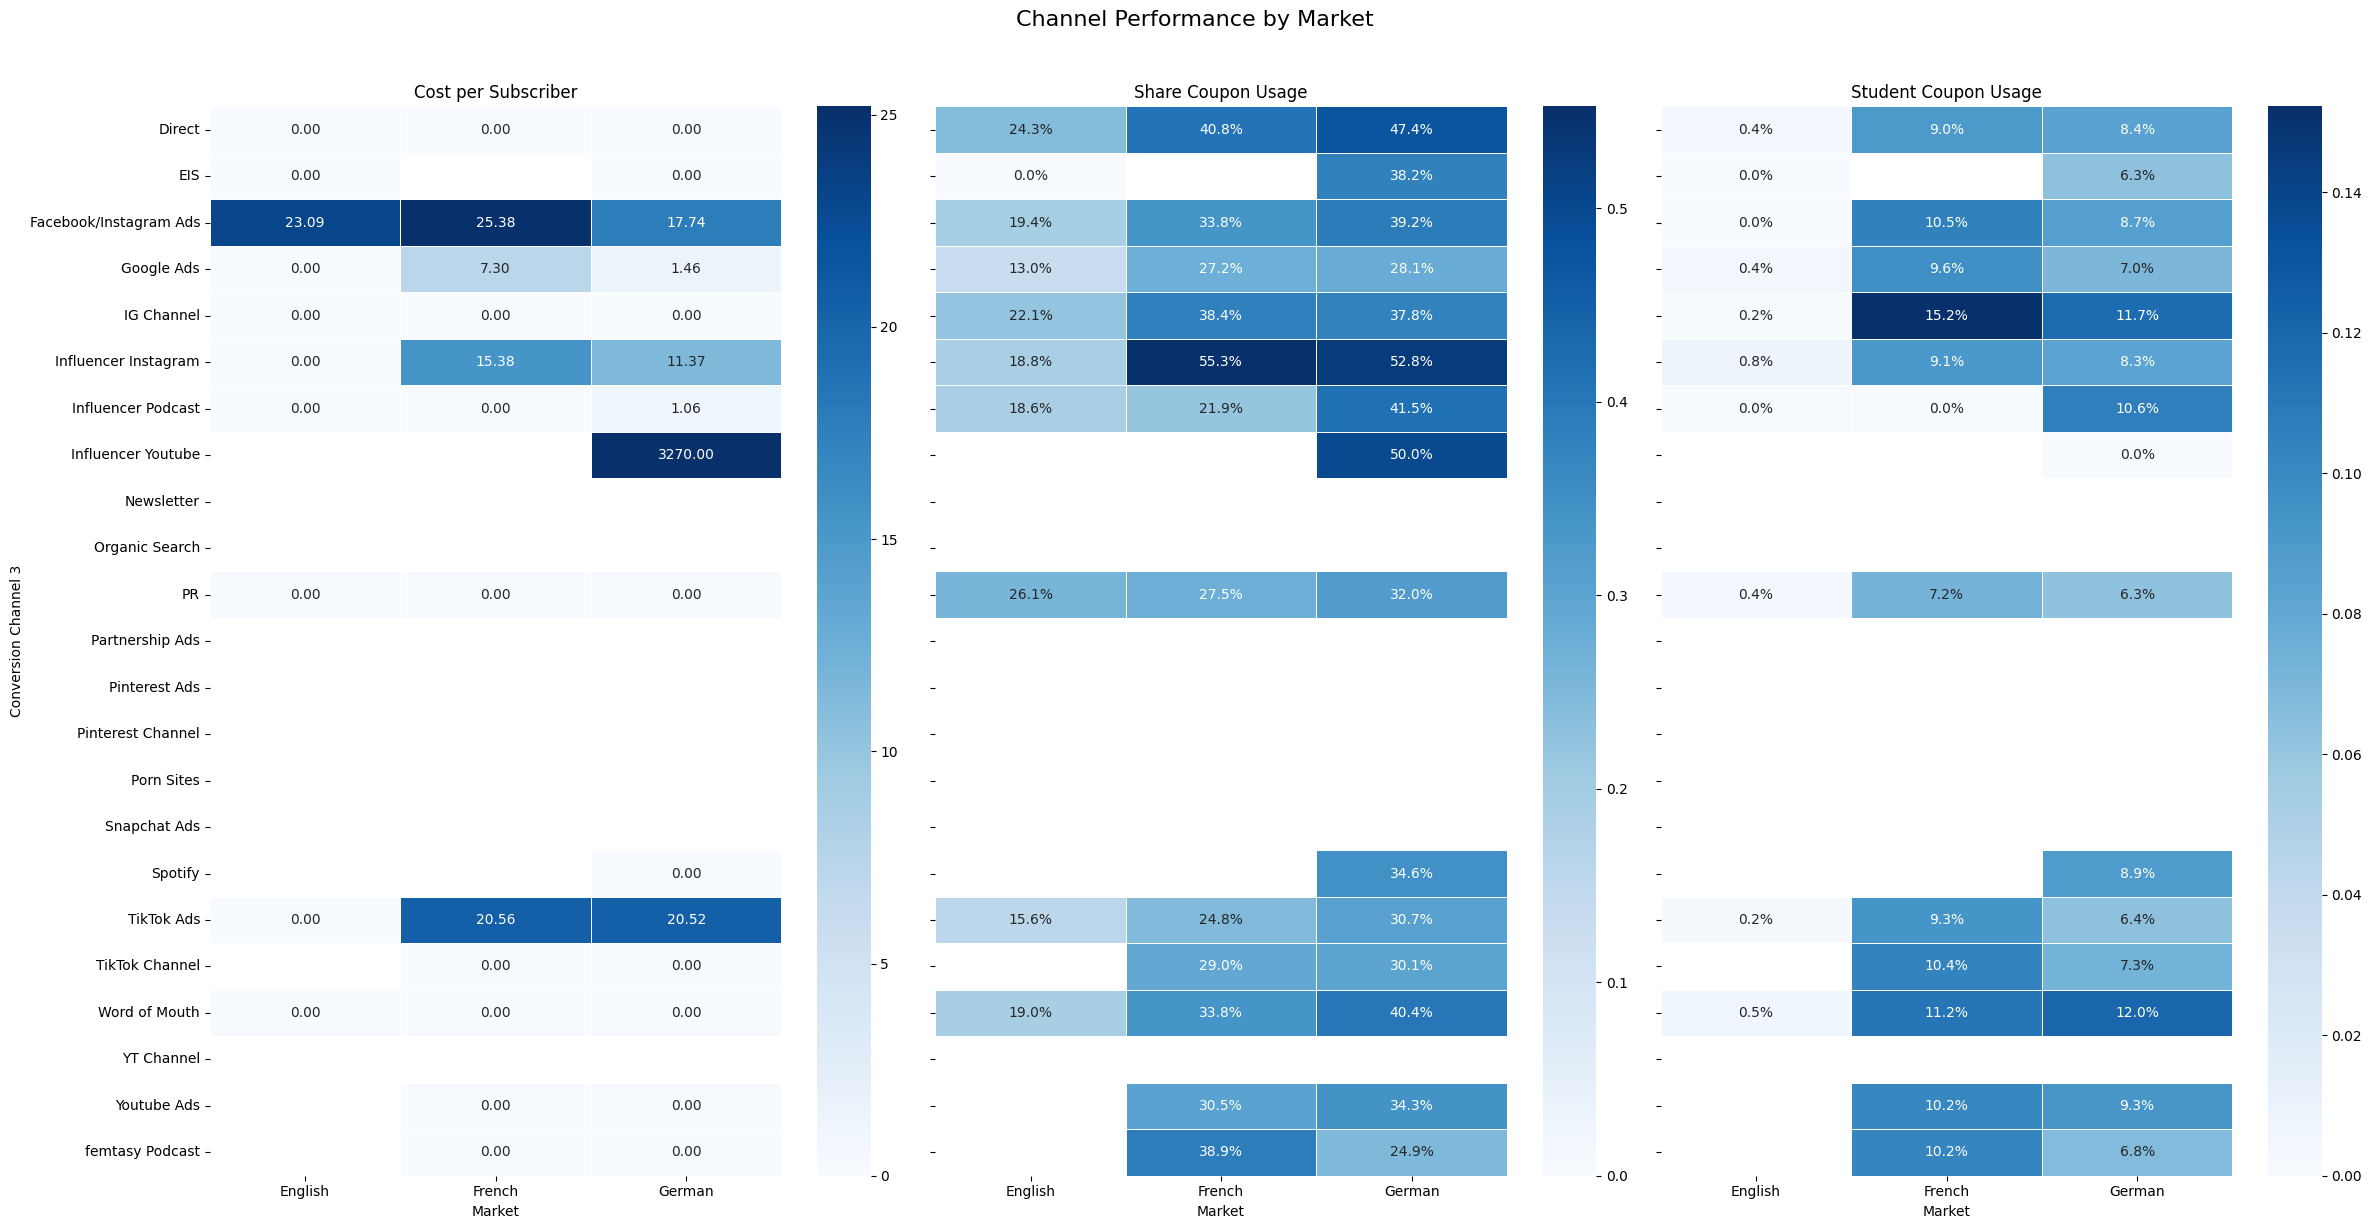

In [402]:
share_check = (
    df_clean
    .groupby(['Market', 'Conversion Channel 3'], as_index=False)
    .agg({
        'Marketing Spending': 'sum',
        'Subscriber': 'sum',
        'Subscriber thru Share': 'sum',
        'Subscriber Student': 'sum',
        'Yearly Paid Conversions': 'sum',
        'Yearly Conversions': 'sum',
        'New Revenue Create Date': 'sum',
        'New Revenue Invoice Date': 'sum'
    })
)

share_check['Cost per Subscriber'] = np.where(
    share_check['Subscriber'] > 0,
    share_check['Marketing Spending'] / share_check['Subscriber'],
    np.nan
)

share_check['Share Coupon'] = np.where(
    share_check['Subscriber'] > 0,
    share_check['Subscriber thru Share'] / share_check['Subscriber'],
    np.nan
)

share_check['Student Coupon'] = np.where(
    share_check['Subscriber'] > 0,
    share_check['Subscriber Student'] / share_check['Subscriber'],
    np.nan
)

share_check['Yearly PCR'] = np.where(
    share_check['Yearly Paid Conversions'] > 0,
    share_check['Yearly Paid Conversions'] / share_check['Yearly Conversions'],
    np.nan
)


markets = ['English', 'French', 'German']

metrics = [
    'Cost per Subscriber',
    'Share Coupon',
    'Student Coupon'
]

markets = ['English', 'French', 'German']

metrics = [
    'Cost per Subscriber',
    'Share Coupon',
    'Student Coupon'
]

markets = ['English', 'French', 'German']

metrics = [
    'Cost per Subscriber',
    'Share Coupon',
    'Student Coupon'
]

titles = ['Cost per Subscriber', 'Share Coupon Usage', 'Student Coupon Usage']

cost_vmax = share_check['Cost per Subscriber'].quantile(0.97)

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(24, 12),
    sharey=True
)

for ax, metric, title in zip(axes, metrics, titles):

    heatmap_data = share_check.pivot(
        index='Conversion Channel 3',
        columns='Market',
        values=metric
    )

    heatmap_data = heatmap_data.reindex(columns=markets)

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.2f' if metric == 'Cost per Subscriber' else '.1%',
        cmap='Blues',
        linewidths=0.5,
        ax=ax,
        cbar=True,
        vmax=cost_vmax if metric == 'Cost per Subscriber' else None
    )

    ax.set_title(title)
    ax.set_xlabel('Market')

axes[0].set_ylabel('Conversion Channel 3')
axes[1].set_ylabel('')
axes[2].set_ylabel('')

plt.suptitle(
    'Channel Performance by Market',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
# plt.savefig('Cupon Usage.png')
plt.show()

# How does Share Coupon affect Yearly Paid Conversion Rate (PCR)
- We see that higher Share Coupon Usage does have a positive effect on Yearly PCR
- There is a .75 correlation indicating a strong positive relationship. The higher Share Coupon usage is, the higher the yearly PCR is.
- The Boxplot shows the distribution of yearly PCR giving us an idea about typical distribution. It's hard to judge how good the values are without additional outside input.

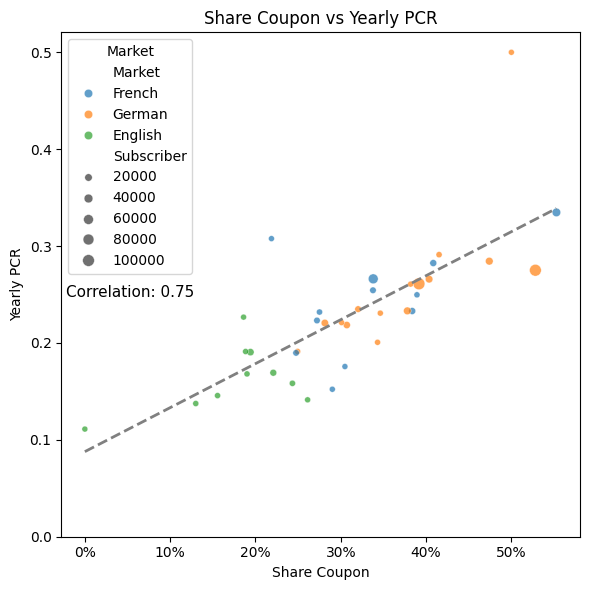

,Market,Conversion Channel 3,Marketing Spending,Subscriber,Subscriber thru Share,Subscriber Student,Yearly Paid Conversions,Yearly Conversions,New Revenue Create Date,New Revenue Invoice Date,Cost per Subscriber,Share Coupon,Student Coupon,Yearly PCR
0,German,Influencer Youtube,6540,2,1.0,0.0,1,2,80.0,80.0,3270.000000,0.500000,0.000000,0.500000
1,French,Influencer Instagram,553872,36020,19912.0,3277.0,11441,34178,495403.0,484731.0,15.376791,0.552804,0.090977,0.334747
2,French,Influencer Podcast,0,32,7.0,0.0,8,26,676.0,765.0,0.000000,0.218750,0.000000,0.307692
3,German,Influencer Podcast,2700,2548,1058.0,270.0,674,2315,40805.0,38720.0,1.059655,0.415228,0.105965,0.291145
4,German,Direct,0,23372,11081.0,1969.0,6199,21797,403159.0,378055.0,0.000000,0.474114,0.084246,0.284397
5,French,Direct,0,12465,5091.0,1124.0,3280,11612,224511.0,213497.0,0.000000,0.408424,0.090172,0.282466
6,German,Influencer Instagram,1145012,100721,53197.0,8392.0,26097,94882,1167819.0,1119765.0,11.368156,0.528162,0.083319,0.275047
7,French,Facebook/Instagram Ads,1519511,59875,20241.0,6301.0,14933,56101,722426.0,698806.0,25.378054,0.338054,0.105236,0.266181
8,German,Word of Mouth,0,20817,8401.0,2503.0,5049,18994,337245.0,324890.0,0.000000,0.403564,0.120238,0.265821
9,German,Facebook/Instagram Ads,1814181,102261,40052.0,8859.0,25182,96453,1166163.0,1116587.0,17.740693,0.391664,0.086631,0.261081


In [429]:
share_coupon_revenue_corr = (
    share_check
    .query('Subscriber > 0')
    .sort_values(by='Share Coupon', ascending=False)
)

plt.figure(figsize=(6, 6))

ax = sns.scatterplot(
    data=share_coupon_revenue_corr,
    x='Share Coupon',
    y='Yearly PCR',
    size='Subscriber',
    hue='Market',
    alpha=0.7
)

sns.regplot(
    data=share_coupon_revenue_corr,
    x='Share Coupon',
    y='Yearly PCR',
    ax=ax,
    scatter=False,
    color='gray',
    ci=None,
    line_kws={
        'linestyle': '--',
        'linewidth': 2
    }
)

corr = share_coupon_revenue_corr['Share Coupon'].corr(
    share_coupon_revenue_corr['Yearly PCR']
)

# Move annotation lower
ax.annotate(
    f'Correlation: {corr:.2f}',
    xy=(0.01, 0.5),
    xycoords='axes fraction',
    ha='left',
    va='top',
    fontsize=11
)

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

# ax.yaxis.set_major_formatter(
#     mtick.FuncFormatter(lambda x, _: f'{x:,.0f}')
# )

ax.set_ylim(bottom=0)

ax.set_title('Share Coupon vs Yearly PCR')
ax.set_xlabel('Share Coupon')
ax.set_ylabel('Yearly PCR')

# Put legend inside where annotation used to be
ax.legend(
    title='Market',
    loc='upper left',
    frameon=True
)

plt.tight_layout()
plt.savefig('Share Coupon Yearly PCR Correlation.png')
plt.show()
share_check.query('`Share Coupon` > 0').sort_values(by='Yearly PCR', ascending=False).reset_index().drop(columns='index')

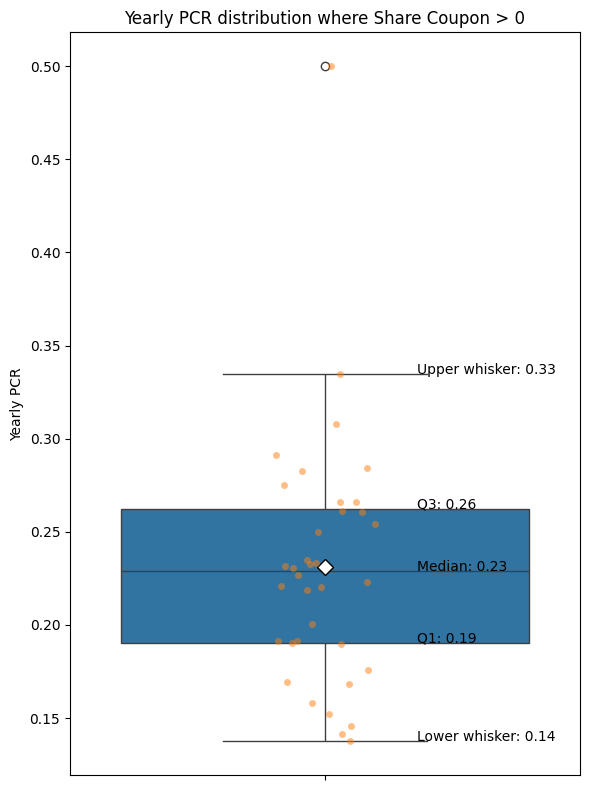

In [430]:
data = share_check.query('`Share Coupon` > 0')['Yearly PCR']

q1 = data.quantile(0.25)
median = data.median()
q3 = data.quantile(0.75)
mean = data.mean()

iqr = q3 - q1
lower_whisker = data[data >= q1 - 1.5 * iqr].min()
upper_whisker = data[data <= q3 + 1.5 * iqr].max()

fig, ax = plt.subplots(figsize=(6, 8))

# Boxplot
sns.boxplot(
    y=data,
    ax=ax,
    showmeans=True,
    meanprops={
        'marker': 'D',
        'markerfacecolor': 'white',
        'markeredgecolor': 'black',
        'markersize': 8
    }
)

# Individual points
sns.stripplot(
    y=data,
    ax=ax,
    alpha=0.5,
    jitter=True
)

# Annotation helper
x_pos = 0.18

ax.annotate(f'Median: {median:.2f}', xy=(0, median), xytext=(x_pos, median))
# ax.annotate(f'Mean: {mean:.2f}', xy=(0, mean), xytext=(x_pos, mean))
ax.annotate(f'Q1: {q1:.2f}', xy=(0, q1), xytext=(x_pos, q1))
ax.annotate(f'Q3: {q3:.2f}', xy=(0, q3), xytext=(x_pos, q3))
ax.annotate(f'Lower whisker: {lower_whisker:.2f}', xy=(0, lower_whisker), xytext=(x_pos, lower_whisker))
ax.annotate(f'Upper whisker: {upper_whisker:.2f}', xy=(0, upper_whisker), xytext=(x_pos, upper_whisker))

ax.set_title('Yearly PCR distribution where Share Coupon > 0')
ax.set_ylabel('Yearly PCR')
ax.set_xlabel('')

plt.tight_layout()
plt.show()

# Marketing Spend vs Invoiced Revenue (ROI)
- I am using Marketing Spending as a stand-in for Investment
- Invoiced Revenue as a stand-in for Revenue
- We are seeing that the German market is the only one with an ROI >1 which means that the Marketing spend in other markets is higher than Invoiced Revenue. This may not be sustainable in the long term
- In the following Cells you find ROI, Revenue per Subscriber per layer and per Market

In [319]:
roi = (
    df_clean
    .groupby(['Market'], as_index=False)
    .agg({
        'Marketing Spending': 'sum',
        'Subscriber': 'sum',
        'New Revenue Create Date': 'sum',
        'New Revenue Invoice Date': 'sum'
    })
)

roi['Created Date ROI'] = roi['New Revenue Create Date'] / roi['Marketing Spending']
roi['Invoice Date ROI'] = roi['New Revenue Invoice Date'] / roi['Marketing Spending']
roi['Revenue per Subscriber'] = roi['New Revenue Invoice Date'] / roi['Subscriber']

roi

,Market,Marketing Spending,Subscriber,New Revenue Create Date,New Revenue Invoice Date,Created Date ROI,Invoice Date ROI,Revenue per Subscriber
0,English,380497,36659,421620.0,329614.0,1.108077,0.866272,8.991353
1,French,2257505,146347,1971891.0,1910754.0,0.873482,0.846401,13.056325
2,German,3309947,320022,4020313.0,3863316.0,1.214616,1.167184,12.072033


In [325]:
roi_cc1 = (
    df_clean
    .groupby(['Market', 'Conversion Channel 1'])
    .agg({
        'Marketing Spending': 'sum',
        'Subscriber': 'sum',
        'New Revenue Create Date': 'sum',
        'New Revenue Invoice Date': 'sum'
    })
)

roi_cc1['Created Date ROI'] = roi_cc1['New Revenue Create Date'] / roi_cc1['Marketing Spending']
roi_cc1['Invoice Date ROI'] = roi_cc1['New Revenue Invoice Date'] / roi_cc1['Marketing Spending']
roi_cc1['Revenue per Subscriber'] = roi_cc1['New Revenue Invoice Date'] / roi_cc1['Subscriber']
roi_cc1[['Marketing Spending', 'Subscriber', 'Invoice Date ROI', 'Revenue per Subscriber']]

Marketing Spending  Subscriber  \
Market  Conversion Channel 1                                   
English Non-Paid                               0       16375   
        Paid                              380497       20284   
French  Non-Paid                               0       36941   
        Paid                             2257505      109406   
German  Non-Paid                               0       80467   
        Paid                             3309947      239555   

                              Invoice Date ROI  Revenue per Subscriber  
Market  Conversion Channel 1                                            
English Non-Paid                           inf               10.140885  
        Paid                          0.429851                8.063350  
French  Non-Paid                           inf               16.064671  
        Paid                          0.583524               12.040555  
German  Non-Paid                           inf               15.161681  
        Paid                          0.798593               11.034213

In [324]:
roi_cc2 = (
    df_clean.query('`Conversion Channel 1` == "Paid"')
    .groupby(['Market', 'Conversion Channel 2'])
    .agg({
        'Marketing Spending': 'sum',
        'Subscriber': 'sum',
        'New Revenue Create Date': 'sum',
        'New Revenue Invoice Date': 'sum'
    })
)

roi_cc2['Created Date ROI'] = roi_cc2['New Revenue Create Date'] / roi_cc2['Marketing Spending']
roi_cc2['Invoice Date ROI'] = roi_cc2['New Revenue Invoice Date'] / roi_cc2['Marketing Spending']
roi_cc2['Revenue per Subscriber'] = roi_cc2['New Revenue Invoice Date'] / roi_cc2['Subscriber']

roi_cc2[['Marketing Spending', 'Subscriber', 'Invoice Date ROI', 'Revenue per Subscriber']]

Marketing Spending  Subscriber  \
Market  Conversion Channel 2                                    
English Influencer                              0        1089   
        Performance Marketing              380497       19195   
French  Influencer                         553872       36052   
        Performance Marketing             1703633       73354   
German  Influencer                        1154252      103271   
        Performance Marketing             2155695      136284   

                               Invoice Date ROI  Revenue per Subscriber  
Market  Conversion Channel 2                                             
English Influencer                          inf               14.061524  
        Performance Marketing          0.389606                7.723053  
French  Influencer                     0.876549               13.466548  
        Performance Marketing          0.488258               11.339709  
German  Influencer                     1.003737               11.218687  
        Performance Marketing          0.688750               10.894426

In [433]:
roi_cc3 = (
    df_clean.query('`Conversion Channel 1` == "Paid" and Subscriber > 0')
    .groupby(['Market', 'Conversion Channel 2', 'Conversion Channel 3'])
    .agg({
        'Marketing Spending': 'sum',
        'Subscriber': 'sum',
        'New Revenue Create Date': 'sum',
        'New Revenue Invoice Date': 'sum'
    })
)

roi_cc3['Created Date ROI'] = roi_cc3['New Revenue Create Date'] / roi_cc3['Marketing Spending']
roi_cc3['Invoice Date ROI'] = roi_cc3['New Revenue Invoice Date'] / roi_cc3['Marketing Spending']
roi_cc3['Revenue per Subscriber'] = roi_cc3['New Revenue Invoice Date'] / roi_cc3['Subscriber']

(roi_cc3[['Marketing Spending', 'Subscriber', 'Invoice Date ROI', 'Revenue per Subscriber']]
    .reset_index()
    .sort_values(by=['Market','Revenue per Subscriber'], ascending=[True,False])
 )

,Market,Conversion Channel 2,Conversion Channel 3,Marketing Spending,Subscriber,Invoice Date ROI,Revenue per Subscriber
1,English,Influencer,Influencer Podcast,0,86,inf,17.127907
0,English,Influencer,Influencer Instagram,0,1003,inf,13.798604
4,English,Performance Marketing,TikTok Ads,0,1350,inf,10.188889
3,English,Performance Marketing,Google Ads,0,1369,inf,9.764792
2,English,Performance Marketing,Facebook/Instagram Ads,380497,16476,0.318323,7.351360
6,French,Influencer,Influencer Podcast,0,32,inf,23.906250
5,French,Influencer,Influencer Instagram,553872,36020,0.875168,13.457274
10,French,Performance Marketing,Youtube Ads,0,246,inf,12.195122
7,French,Performance Marketing,Facebook/Instagram Ads,1519511,59875,0.459889,11.671081
8,French,Performance Marketing,Google Ads,48483,6637,1.377906,10.065542


In [343]:
(roi_cc3[['Marketing Spending', 'Subscriber', 'Invoice Date ROI', 'Revenue per Subscriber']]
    .reset_index()
    .sort_values(by=['Conversion Channel 3', 'Market'], ascending=[True,True])
 )

,Market,Conversion Channel 2,Conversion Channel 3,Marketing Spending,Subscriber,Invoice Date ROI,Revenue per Subscriber
2,English,Performance Marketing,Facebook/Instagram Ads,380497,16476,0.318323,7.351360
7,French,Performance Marketing,Facebook/Instagram Ads,1519511,59875,0.459889,11.671081
14,German,Performance Marketing,Facebook/Instagram Ads,1814181,102261,0.615477,10.918992
3,English,Performance Marketing,Google Ads,0,1369,inf,9.764792
8,French,Performance Marketing,Google Ads,48483,6637,1.377906,10.065542
15,German,Performance Marketing,Google Ads,26640,18215,7.707432,11.272358
0,English,Influencer,Influencer Instagram,0,1003,inf,13.798604
5,French,Influencer,Influencer Instagram,553872,36020,0.875168,13.457274
11,German,Influencer,Influencer Instagram,1145012,100721,0.977950,11.117493
1,English,Influencer,Influencer Podcast,0,86,inf,17.127907


# Misalignment between Marketing Spend and Subscriber
- I saw quite a few Channels that are Paid, but don't show any Marketing Spend. This indicates that Marketing Spend was not mapped properly to the channels which skews cost ratios.
- Below there is a monthly overview where we see subscription numbers for these "paid channels that have 0 cost"

In [336]:
paid_zero_spend_subs = df_clean[
    (df_clean['Conversion Channel 1'] == 'Paid') &
    (df_clean['Marketing Spending'] == 0) &
    (df_clean['Subscriber'] > 0)
]

paid_zero_spend_summary = (
    paid_zero_spend_subs
    .groupby([
        'Market',
        'Conversion Channel 2',
        'Conversion Channel 3'
    ], as_index=False)
    .agg(
        subscribers=('Subscriber', 'sum'),
        marketing_spend=('Marketing Spending', 'sum')
    )
    .sort_values('subscribers', ascending=False)
)

paid_zero_spend_summary

,Market,Conversion Channel 2,Conversion Channel 3,subscribers,marketing_spend
10,German,Performance Marketing,Google Ads,8680,0
8,German,Influencer,Influencer Podcast,1801,0
6,French,Performance Marketing,TikTok Ads,1490,0
3,English,Performance Marketing,Google Ads,1369,0
4,English,Performance Marketing,TikTok Ads,1350,0
11,German,Performance Marketing,TikTok Ads,1094,0
0,English,Influencer,Influencer Instagram,1003,0
12,German,Performance Marketing,Youtube Ads,647,0
7,French,Performance Marketing,Youtube Ads,246,0
2,English,Performance Marketing,Facebook/Instagram Ads,89,0


In [339]:
paid_zero_spend_summary = (
    paid_zero_spend_subs
    .groupby([
        'Business Month',
        'Market',
        'Conversion Channel 2',
        'Conversion Channel 3'
    ], as_index=False)
    .agg(
        subscribers=('Subscriber', 'sum'),
        marketing_spend=('Marketing Spending', 'sum')
    )
    .sort_values('subscribers', ascending=False)
)

paid_zero_spend_summary.pivot_table(index=['Market','Conversion Channel 3'], columns='Business Month', values='subscribers')

Business Month                     1      2      3      4      5       6   \
Market  Conversion Channel 3                                                
English Facebook/Instagram Ads    4.0    6.0    9.0    4.0    6.0     8.0   
        Google Ads               45.0   33.0   26.0   26.0   29.0    56.0   
        Influencer Instagram     20.0   20.0   21.0   22.0   30.0    40.0   
        Influencer Podcast        3.0    6.0    1.0    5.0    4.0     4.0   
        TikTok Ads               27.0   10.0   12.0   18.0   10.0    16.0   
French  Influencer Podcast        2.0    2.0    3.0    2.0    1.0     2.0   
        TikTok Ads                NaN    NaN    NaN    NaN    NaN     NaN   
        Youtube Ads              12.0   18.0   13.0   16.0    9.0    23.0   
German  Google Ads                NaN    NaN    NaN    NaN    NaN  1285.0   
        Influencer Podcast      196.0  183.0  188.0  180.0  209.0   181.0   
        Influencer Youtube        NaN    NaN    NaN    1.0    NaN     NaN   
        TikTok Ads                NaN    NaN    NaN    NaN    NaN     NaN   
        Youtube Ads              21.0   39.0   64.0   30.0   50.0    52.0   

Business Month                      7       8       9       10      11      12  
Market  Conversion Channel 3                                                    
English Facebook/Instagram Ads    20.0    32.0     NaN     NaN     NaN     NaN  
        Google Ads                60.0    71.0   128.0   317.0   262.0   316.0  
        Influencer Instagram      51.0    66.0   122.0   235.0   188.0   188.0  
        Influencer Podcast         5.0    10.0     6.0    15.0    11.0    16.0  
        TikTok Ads                43.0    53.0   119.0   379.0   346.0   317.0  
French  Influencer Podcast         3.0     4.0     3.0     3.0     5.0     2.0  
        TikTok Ads                 NaN   446.0   283.0   346.0   236.0   179.0  
        Youtube Ads               22.0    40.0    36.0    20.0    14.0    23.0  
German  Google Ads              1257.0  1419.0  1208.0  1298.0  1030.0  1183.0  
        Influencer Podcast         NaN   176.0   176.0     NaN   150.0   162.0  
        Influencer Youtube         NaN     NaN     NaN     NaN     NaN     1.0  
        TikTok Ads                 NaN     NaN     NaN   446.0   332.0   316.0  
        Youtube Ads               60.0    72.0    64.0    79.0    57.0    59.0